**codon position work**

Overall SNP counts per codon position (combined species)

  Codon position            Count   Proportion
  1st position             66,279       31.2%
  2nd position             53,919       25.4%
  3rd position             92,422       43.5%

  Test 1: Pairwise comparisons between codon positions:

  Position 1           Position 2               chi2     p_bonf
  1st position         2nd position          1270.98   0.000000
  1st position         3rd position          4306.57   0.000000
  2nd position         3rd position         10130.32   0.000000
TEST 2: Goodness-of-fit per species( is codon distribution uneven?
        species     chi2  df        p_raw    p_fdr  significant  prop_pos1  prop_pos2  prop_pos3 favoured_position
     bpertussis  15.9235   2 3.485447e-04 0.004880         True     0.3134     0.3918     0.2948      2nd position
        cjejuni  28.6671   2 5.956802e-07 0.000008         True     0.4009     0.2627     0.3364      1st position
          ecoli  82.9312   2 9.

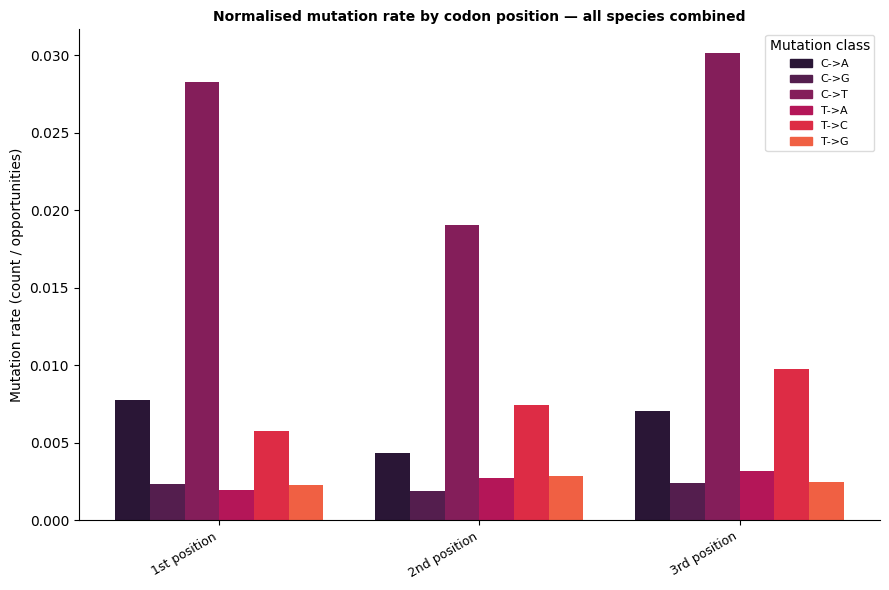

Saved plot1a_grouped_normalised_all_species.png


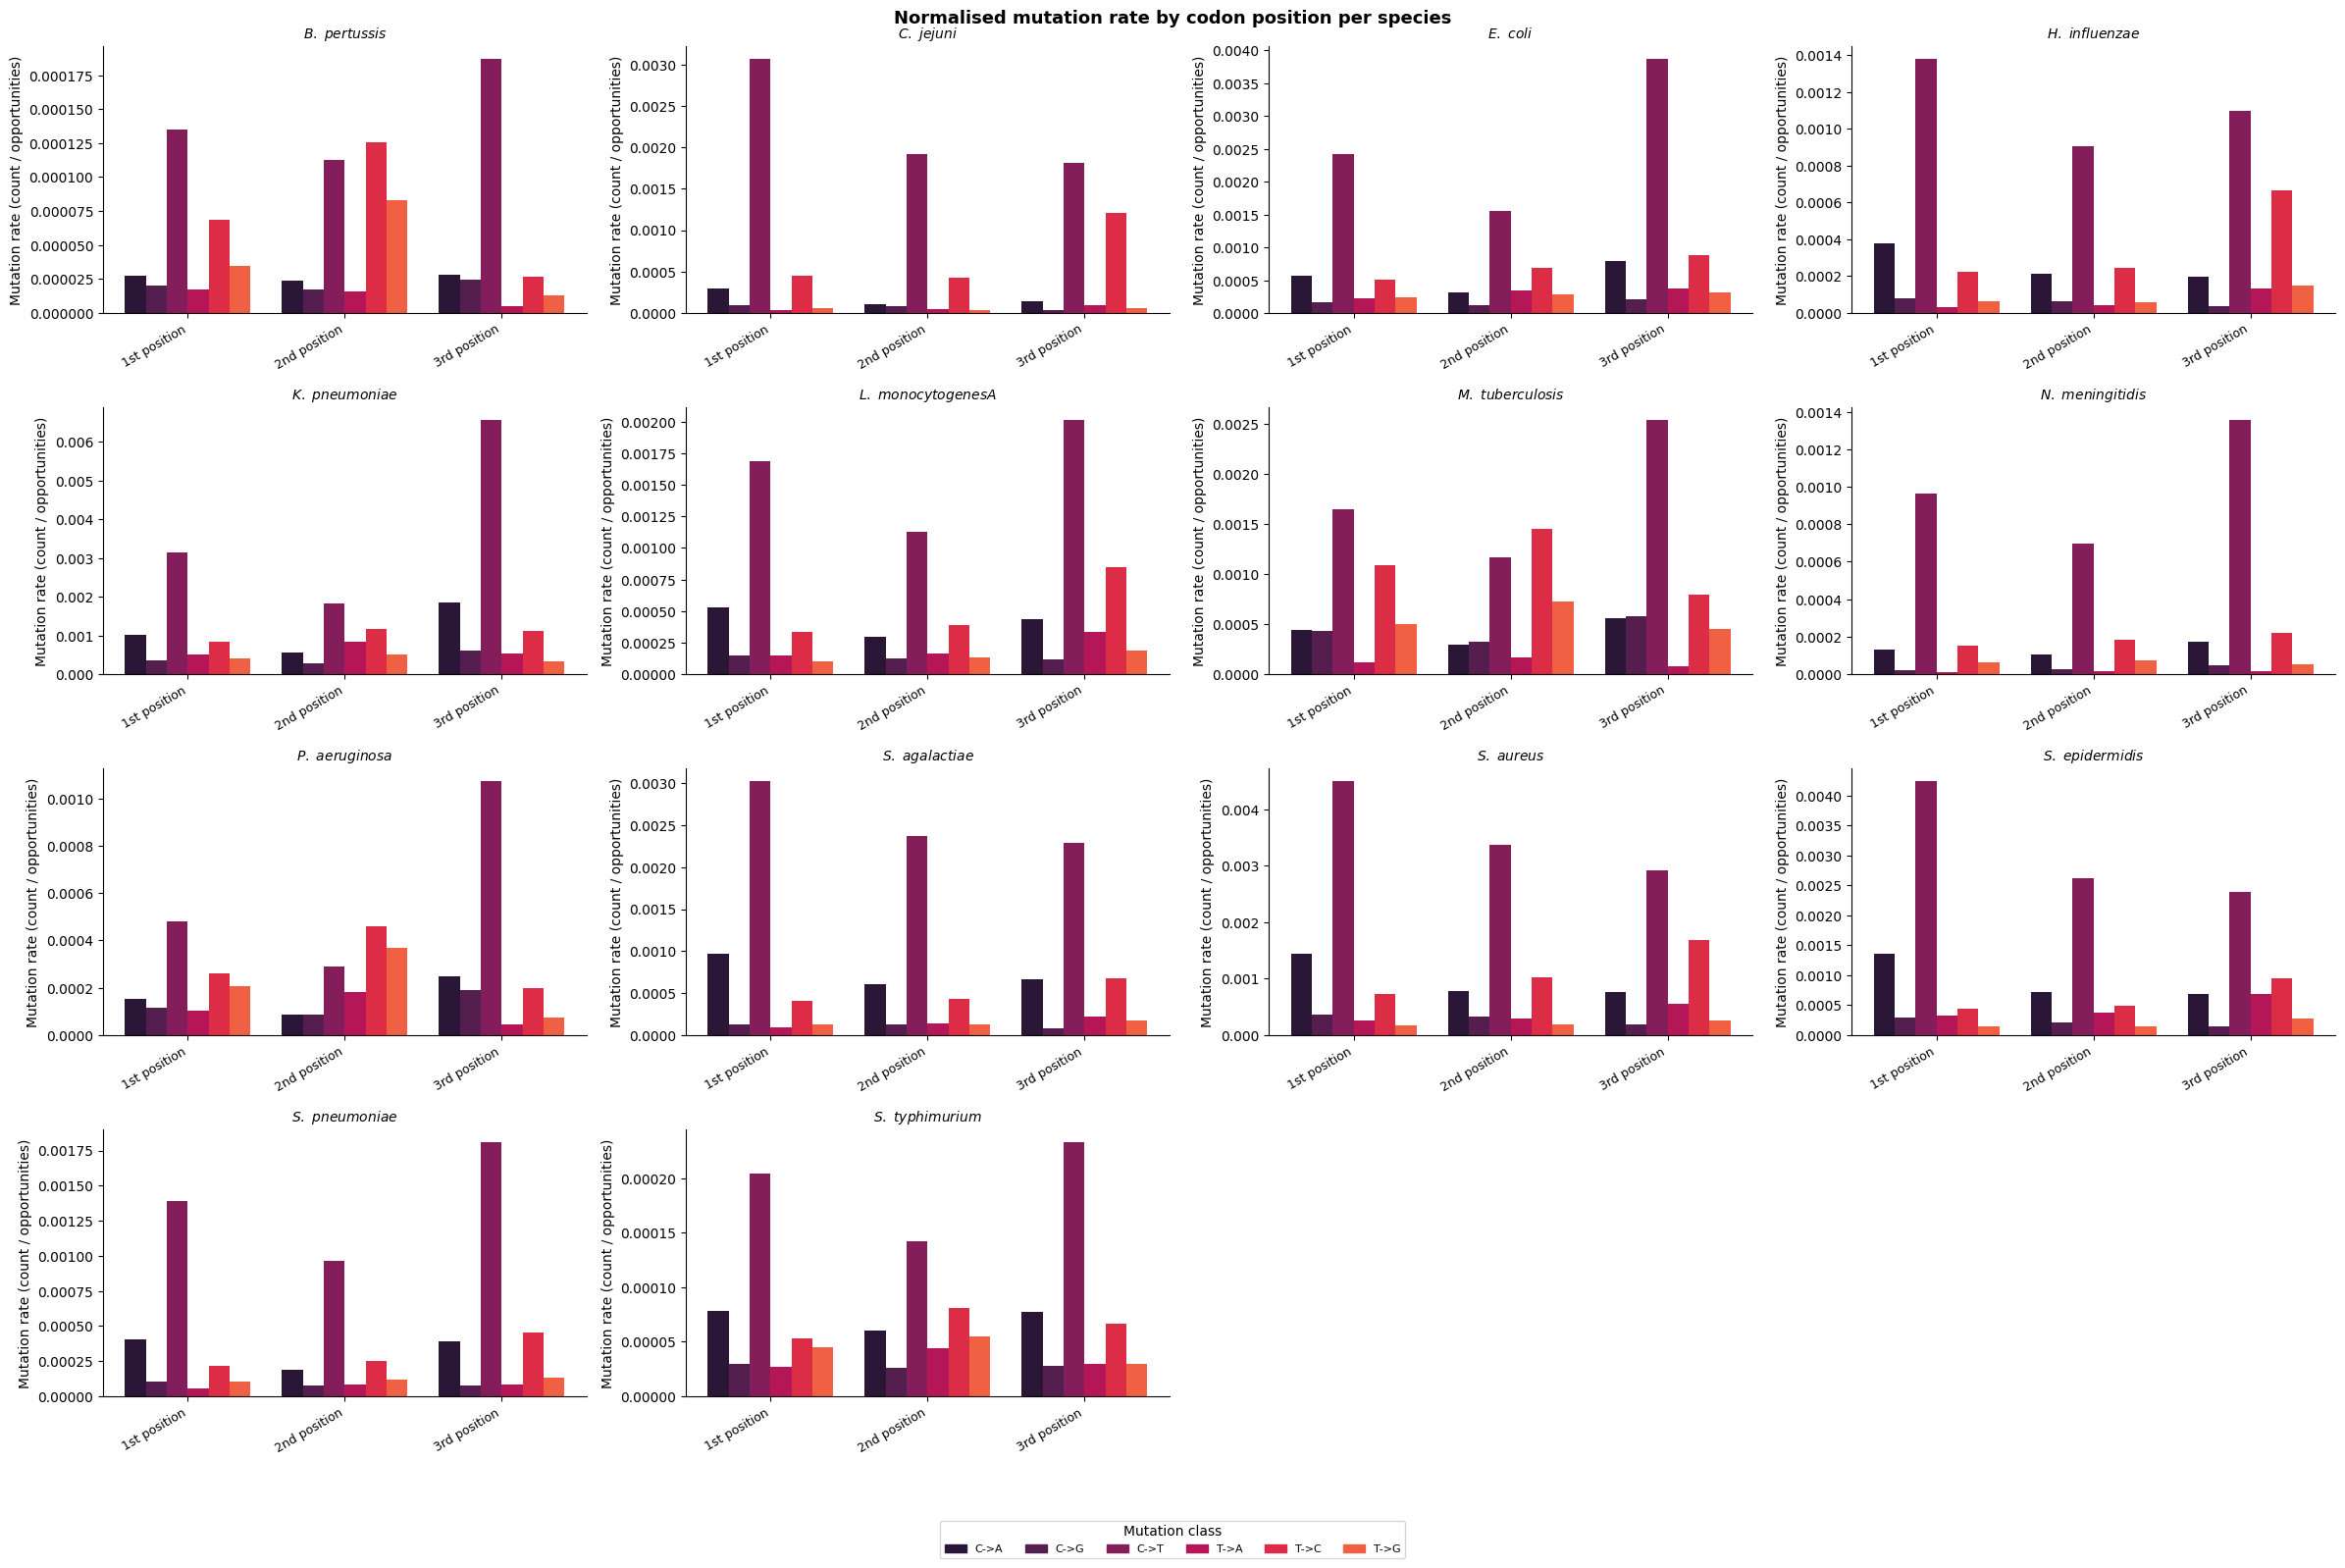

Saved plot1b_grouped_normalised_per_species.png


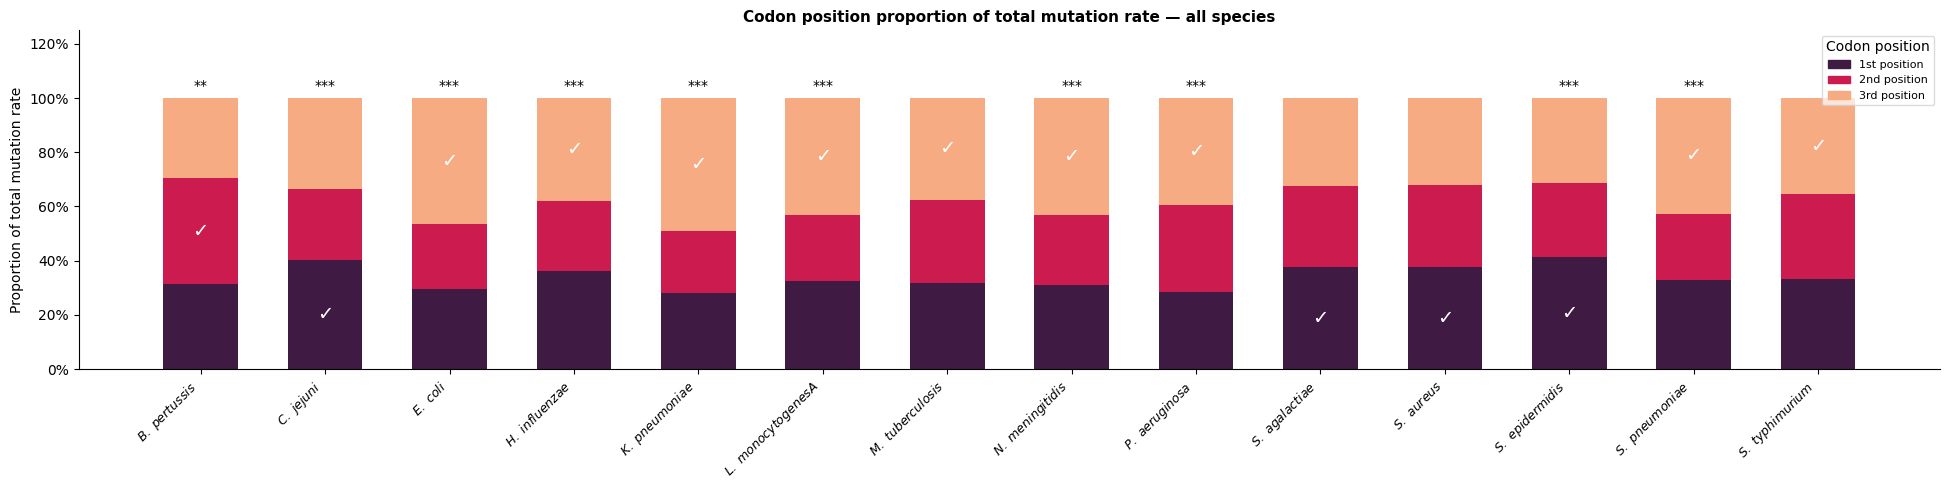

Saved plot2_codon_proportional_all_species.png


In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chisquare, chi2 as chi2_dist, chi2_contingency
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# define paths
base_folder = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/"
)
output_folder = os.path.join(base_folder, "charts", "codon_position")
csv_path      = os.path.join(base_folder, "mutation_summary_final_c.csv")

os.makedirs(output_folder, exist_ok=True)

# load data
df = pd.read_csv(csv_path)

df = df[df["codon_position"] != "intergenic"].copy()

df["mutation_rate"] = np.where(
    df["opportunities"] > 0,
    df["no_mutations"] / df["opportunities"],
    0
)

# define mutation classes and colours
MUT_CLASSES  = ["C->A", "C->G", "C->T", "T->A", "T->C", "T->G"]
CODON_LABELS = ["codon_pos_1", "codon_pos_2", "codon_pos_3"]
CODON_DISPLAY = {
    "codon_pos_1": "1st position",
    "codon_pos_2": "2nd position",
    "codon_pos_3": "3rd position",
}

ROCKET_6    = sns.color_palette("rocket", 8)
MUT_COLOURS = {
    "C->A": ROCKET_6[0],
    "C->G": ROCKET_6[1],
    "C->T": ROCKET_6[2],
    "T->A": ROCKET_6[3],
    "T->C": ROCKET_6[4],
    "T->G": ROCKET_6[5],
}

ROCKET_3      = sns.color_palette("rocket", 5)
CODON_COLOURS = {
    "codon_pos_1": ROCKET_3[0],
    "codon_pos_2": ROCKET_3[2],
    "codon_pos_3": ROCKET_3[4],
}

SPECIES_LIST = sorted(df["species"].unique())
N_SPECIES    = len(SPECIES_LIST)
DPI          = 150


############
#functions 
def format_species_name(name):
    parts = name.split("_") if "_" in name else [name[:1], name[1:]]
    genus = parts[0][0].upper() + parts[0][1:]
    rest  = " ".join(parts[1:]) if len(parts) > 1 else ""
    return f"$\\it{{{genus}.\\ {rest}}}$" if rest else f"$\\it{{{genus}}}$"


def pivot_rate(data, index):
    pt = data.pivot_table(
        index=index, columns="mutation_class",
        values="mutation_rate", aggfunc="sum", fill_value=0
    )
    pt = pt.reindex(columns=[c for c in MUT_CLASSES if c in pt.columns], fill_value=0)
    return pt


def codon_reindex(pt):
    pt      = pt.reindex([c for c in CODON_LABELS if c in pt.index])
    xlabels = [CODON_DISPLAY[c] for c in pt.index]
    return pt, xlabels


def subplot_grid(n):
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))
    return nrows, ncols


def add_legend_mut(fig):
    handles = [plt.Rectangle((0, 0), 1, 1, color=MUT_COLOURS[mc]) for mc in MUT_CLASSES]
    fig.legend(handles, MUT_CLASSES, title="Mutation class",
               loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.01), fontsize=8)


def add_legend_codon(ax):
    handles = [plt.Rectangle((0, 0), 1, 1, color=CODON_COLOURS[c]) for c in CODON_LABELS]
    labels  = [CODON_DISPLAY[c] for c in CODON_LABELS]
    ax.legend(handles, labels, title="Codon position", fontsize=8,
              loc="upper right", framealpha=0.7)


def significance_stars(p):
    if p < 0.001:  return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else:          return "ns"


def scale_to(row, target=1000):
    total = row.sum()
    return row / total * target if total > 0 else row

nrows, ncols = subplot_grid(N_SPECIES)


# Collapse mutation class — sum rate per species x codon_position
df_codon = (
    df.groupby(["species", "codon_position"])["mutation_rate"]
    .sum()
    .reset_index()
)
pt = df_codon.pivot_table(
    index="species", columns="codon_position",
    values="mutation_rate", fill_value=0
)
pt = pt.reindex(columns=[c for c in CODON_LABELS if c in pt.columns])

##############
#stats

print("Overall SNP counts per codon position (combined species)")

#find codon totals and print in nice format
codon_totals = (
    df.groupby("codon_position")["no_mutations"]
    .sum()
    .reindex([c for c in CODON_LABELS if c in df["codon_position"].unique()])
)

print(f"\n  {'Codon position':<20} {'Count':>10} {'Proportion':>12}")
for pos, count in codon_totals.items():
    print(f"  {CODON_DISPLAY[pos]:<20} {int(count):>10,} {count/total_snps:>11.1%}")

# pairwise for each codon, correct with Bonf
print(f"\n  Test 1: Pairwise comparisons between codon positions:")
pos_labels    = [c for c in CODON_LABELS if c in codon_totals.index]
pair_pvals_t0 = []
for i, j in combinations(range(len(pos_labels)), 2):
    obs_i, obs_j  = codon_totals.iloc[i], codon_totals.iloc[j]
    total_ij      = obs_i + obs_j
    chi2_ij, p_ij = chisquare(f_obs=[obs_i, obs_j], f_exp=[total_ij/2, total_ij/2])
    pair_pvals_t0.append((pos_labels[i], pos_labels[j], chi2_ij, p_ij))

_, p_bonf_pos, _, _ = multipletests([p for _, _, _, p in pair_pvals_t0], method="bonferroni")
print(f"\n  {'Position 1':<20} {'Position 2':<20} {'chi2':>8} {'p_bonf':>10}")

for (l1, l2, chi2_ij, _), p_b in zip(pair_pvals_t0, p_bonf_pos):
    print(f"  {CODON_DISPLAY[l1]:<20} {CODON_DISPLAY[l2]:<20} "
          f"{chi2_ij:>8.2f} {p_b:>10.6f}")


codon_totals_df = pd.DataFrame({
    "codon_position": codon_totals.index,
    "codon_label":    [CODON_DISPLAY[c] for c in codon_totals.index],
    "count":          codon_totals.values.astype(int),
    "proportion":     (codon_totals.values / total_snps).round(4),
})

#############
#test2
print("TEST 2: Goodness-of-fit per species( is codon distribution uneven?")

#gets mutation rates for each species at each codon, scales so that it is comparable, build null expectation of even codons
gof_results = []
for sp in SPECIES_LIST:
    observed_rates  = pt.loc[sp].values
    total           = observed_rates.sum()
    if total == 0:
        continue
    observed_scaled = scale_to(observed_rates)
    expected_equal  = np.full(len(CODON_LABELS), 1000 / len(CODON_LABELS))
    chi2_val        = np.sum((observed_scaled - expected_equal) ** 2 / expected_equal)
    p_val           = chi2_dist.sf(chi2_val, len(CODON_LABELS) - 1)
    props           = observed_rates / total

    gof_results.append({
        "species":           sp,
        "chi2":              round(chi2_val, 4),
        "df":                len(CODON_LABELS) - 1,
        "p_raw":             p_val,
        "prop_pos1":         round(props[0], 4),
        "prop_pos2":         round(props[1], 4),
        "prop_pos3":         round(props[2], 4),
        "favoured_position": CODON_DISPLAY[CODON_LABELS[np.argmax(observed_rates)]],
    })

#correct with Bonf, get second value from multipletests
gof_df              = pd.DataFrame(gof_results)
_, p_fdr, _, _      = multipletests(gof_df["p_raw"], method="bonferroni")
gof_df["p_fdr"]     = p_fdr.round(6)
gof_df["significant"] = p_fdr < 0.05

print(gof_df[["species", "chi2", "df", "p_raw", "p_fdr",
              "significant", "prop_pos1", "prop_pos2", "prop_pos3",
              "favoured_position"]].to_string(index=False))


gof_df.to_csv(os.path.join(output_folder, "codon_gof_per_species.csv"), index=False)
print("Saved: codon_gof_per_species.csv")

#so i can add sig asterisk and tick marks in favoured codon
gof_sig_by_species = dict(zip(gof_df["species"], gof_df["p_fdr"]))
favour_lookup      = dict(zip(gof_df["species"], gof_df["favoured_position"]))

#############plots

def plot_grouped(data, ax, title):
    pt, xlabels = codon_reindex(pivot_rate(data, index="codon_position"))
    n_bars = len(pt.columns)
    width  = 0.8 / n_bars
    x      = np.arange(len(pt))

    for j, mc in enumerate(pt.columns):
        offset = (j - n_bars / 2 + 0.5) * width
        ax.bar(x + offset, pt[mc].values, width=width,
               color=MUT_COLOURS[mc], label=mc)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Mutation rate (count / opportunities)")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.spines[["top", "right"]].set_visible(False)

#plot1: species aggregated, show and save
fig, ax = plt.subplots(figsize=(9, 6))
plot_grouped(df, ax, title="Normalised mutation rate by codon position — all species combined")
handles = [plt.Rectangle((0, 0), 1, 1, color=MUT_COLOURS[mc]) for mc in MUT_CLASSES]
ax.legend(handles, MUT_CLASSES, title="Mutation class", fontsize=8,
          loc="upper right", framealpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "plot1a_grouped_normalised_all_species.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved plot1a_grouped_normalised_all_species.png")

#plot1b: normalised mutation rate by codon position per species, show and save
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(6 * ncols, 4 * nrows), sharey=False)
axes_flat = np.array(axes).flatten()
for i, sp in enumerate(SPECIES_LIST):
    plot_grouped(df[df["species"] == sp], axes_flat[i],
                 title=format_species_name(sp))
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
add_legend_mut(fig)
fig.suptitle("Normalised mutation rate by codon position per species",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(output_folder, "plot1b_grouped_normalised_per_species.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved plot1b_grouped_normalised_per_species.png")

#plot 2: proportion of codons for each species, format graphs as before 
pt_prop         = pt.div(pt.sum(axis=1), axis=0)
display_to_key  = {v: k for k, v in CODON_DISPLAY.items()}

x      = np.arange(len(pt_prop))
labels = pt_prop.index.tolist()

fig, ax = plt.subplots(figsize=(max(10, N_SPECIES * 1.4), 5))
bottom = np.zeros(len(pt_prop))
for cl in pt_prop.columns:
    ax.bar(x, pt_prop[cl].values, bottom=bottom,
           color=CODON_COLOURS[cl], label=CODON_DISPLAY[cl], width=0.6)
    bottom += pt_prop[cl].values

ax.set_xticks(x)
ax.set_xticklabels(
    [format_species_name(sp) for sp in labels],
    rotation=45, ha="right", fontsize=9
)
ax.set_ylabel("Proportion of total mutation rate")
ax.set_ylim(0, 1.25)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Codon position proportion of total mutation rate — all species",
             fontsize=11, fontweight="bold")
add_legend_codon(ax)
ax.spines[["top", "right"]].set_visible(False)

for i, sp in enumerate(labels):
    # significance stars for each
    p_sp  = gof_sig_by_species.get(sp, 1.0)
    stars = significance_stars(p_sp)
    if stars != "ns":
        ax.text(x[i], 1.02, stars,
                ha="center", va="bottom", fontsize=10, color="black")

    # tick symbol at midpoint of favoured codon
    fav     = favour_lookup.get(sp, "")
    fav_key = display_to_key.get(fav)
    if fav_key:
        fav_idx  = [c for c in CODON_LABELS if c in pt_prop.columns].index(fav_key)
        bottom_y = pt_prop.iloc[i, :fav_idx].sum()
        top_y    = bottom_y + pt_prop.iloc[i, fav_idx]
        mid_y    = (bottom_y + top_y) / 2
        ax.text(x[i], mid_y, "✓",
                ha="center", va="center", fontsize=14,
                color="white", fontweight="bold", zorder=5)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "plot2_codon_proportional_all_species.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved plot2_codon_proportional_all_species.png")
